# Exploratory Data Analysis (EDA) of a Stratified Forest Cover Type Dataset
This notebook conducts exploratory data analysis of the the small stratified Forest Cover Type multiclass classification dataset `dataset_stratified.csv` in `data/processed` folder

The dataset is treated as the working dataset for supervised multiclass classification. It contains the same feature schema as the full Forest Cover Type dataset, but only 20,000 rows. It covers:

1. Loading the small CSV dataset  
2. Dataset shape, schema, missing-value, duplicate, and binary-feature checks  
3. Target class imbalance analysis  
4. Continuous feature summaries, distributions, and boxplots  
5. Continuous feature behavior by target class  
6. Wilderness-area and soil-type indicator analysis  
7. One-hot consistency checks  
8. Correlation analysis   

> **Repository alignment:** This notebook is structured for the standalone `01-model-benchmarking-and-error-analysis` project root. Inputs are read from `data/raw/covertype/` or `data/processed/`; metrics, runtime tables, model-comparison artifacts, confusion matrices, and figures are written to the project-local `results/` and `figures/` folders.


## 0. Notebook configurations (technical)

In [1]:
# Project-local configuration, paths, and imports
import os
import sys
from pathlib import Path

MODULE_NAME = "01-model-benchmarking-and-error-analysis"
NOTEBOOK_SLUG = "02_eda_dataset_sampled"


def _find_project_root(start: str | Path | None = None) -> Path:
    """Find the 01-model-benchmarking-and-error-analysis project root."""
    start_path = Path(start or os.environ.get("MODEL_BENCHMARK_ROOT", Path.cwd())).resolve()
    for candidate in [start_path, *start_path.parents]:
        if candidate.name == MODULE_NAME and (candidate / "notebooks").exists():
            return candidate
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "src").exists()
            and (candidate / "scripts").exists()
        ):
            return candidate
    return start_path


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.data.project_paths import get_paths
except Exception as exc:
    raise ImportError(
        "Could not import src.data.project_paths. Run this notebook from inside "
        "01-model-benchmarking-and-error-analysis or set MODEL_BENCHMARK_ROOT."
    ) from exc

PATHS = get_paths(PROJECT_ROOT)

RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
DATASET_STRATIFIED_PATH = PATHS.dataset_stratified_path
DATASET_REMAINDER_PATH = PATHS.dataset_remainder_path

RESULTS_METRICS_DIR = PATHS.results_metrics_dir
RESULTS_RUNTIME_DIR = PATHS.results_runtime_dir
RESULTS_MODEL_COMPARISON_DIR = PATHS.results_model_comparison_dir
RESULTS_CONFUSION_MATRICES_DIR = PATHS.results_confusion_matrices_dir

FIG_EDA_DIR = PATHS.figures_eda_dir
FIG_LEARNING_CURVES_DIR = PATHS.figures_learning_curves_dir
FIG_MODEL_COMPLEXITY_DIR = PATHS.figures_model_complexity_dir
FIG_CONFUSION_MATRICES_DIR = PATHS.figures_confusion_matrices_dir
FIG_RUNTIME_DIR = PATHS.figures_runtime_dir

REPORTS_DIR = PATHS.reports_dir

# Backward-compatible aliases used by the original notebooks.
# New output writes below are routed to the specific category folders above.
OUT_DIR = RESULTS_METRICS_DIR
RESULTS_DIR = RESULTS_METRICS_DIR
FIG_DIR = FIG_EDA_DIR if NOTEBOOK_SLUG.startswith(("01_", "02_")) else FIG_MODEL_COMPLEXITY_DIR

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_METRICS_DIR,
    RESULTS_RUNTIME_DIR,
    RESULTS_MODEL_COMPARISON_DIR,
    RESULTS_CONFUSION_MATRICES_DIR,
    FIG_EDA_DIR,
    FIG_LEARNING_CURVES_DIR,
    FIG_MODEL_COMPLEXITY_DIR,
    FIG_CONFUSION_MATRICES_DIR,
    FIG_RUNTIME_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Input protocol:
# - Notebook 01 reads raw covtype.data and creates dataset_stratified.csv + dataset_remainder.csv.
# - Notebooks 02-08 read dataset_stratified.csv for train/validation.
# - Model notebooks also read dataset_remainder.csv for untouched final testing.
DATA_PATH_RAW = RAW_DATA_DIR / "covtype.data"
DATA_PATH = DATASET_STRATIFIED_PATH
DATA_PATH_TEST = DATASET_REMAINDER_PATH
TARGET_COL = "Cover_Type"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
if NOTEBOOK_SLUG not in {'02_eda_dataset_sampled', '01_eda_dataset_original'}:
    print("DATA_PATH_TEST:", DATA_PATH_TEST)
print("Processed data:", PROCESSED_DATA_DIR)
print("Results/metrics:", RESULTS_METRICS_DIR)
print("Results/runtime:", RESULTS_RUNTIME_DIR)
print("Results/model-comparison:", RESULTS_MODEL_COMPARISON_DIR)
print("Results/confusion-matrices:", RESULTS_CONFUSION_MATRICES_DIR)
print("Figures/EDA:", FIG_EDA_DIR)
print("Figures/learning-curves:", FIG_LEARNING_CURVES_DIR)
print("Figures/model-complexity-curves:", FIG_MODEL_COMPLEXITY_DIR)
print("Figures/confusion-matrices:", FIG_CONFUSION_MATRICES_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


PROJECT_ROOT: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis
DATA_PATH: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
Processed data: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed
Results/metrics: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/metrics
Results/runtime: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/runtime
Results/model-comparison: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/model-comparison
Results/confusion-matrices: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/confusion-matrices
Figures/EDA: /home/vision/Repos/ml-model-evaluation-and

## 1. Loading Original Dataset

In [2]:
# checking for loading erros + validation
print(f"Using data path: {DATA_PATH.resolve() if DATA_PATH.exists() else DATA_PATH}")
print(f"File exists: {DATA_PATH.exists()}")
if DATA_PATH.exists():
    print(f"File size: {DATA_PATH.stat().st_size / (1024**2):.2f} MB")

Using data path: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
File exists: True
File size: 2.47 MB


In [3]:
# setting column names and groupping features

continuous_cols = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]

wilderness_cols = [f"Wilderness_Area_{i}" for i in range(1, 5)]
soil_cols = [f"Soil_Type_{i}" for i in range(1, 41)]
binary_cols = wilderness_cols + soil_cols
target_col = "Cover_Type"

expected_columns = continuous_cols + wilderness_cols + soil_cols + [target_col]

len(expected_columns), expected_columns[:5], expected_columns[-5:]

(55,
 ['Elevation',
  'Aspect',
  'Slope',
  'Horizontal_Distance_To_Hydrology',
  'Vertical_Distance_To_Hydrology'],
 ['Soil_Type_37',
  'Soil_Type_38',
  'Soil_Type_39',
  'Soil_Type_40',
  'Cover_Type'])

In [4]:
df = pd.read_csv(DATA_PATH)

#Basic schema validation
missing_expected_cols = sorted(set(expected_columns) - set(df.columns))
extra_cols = sorted(set(df.columns) - set(expected_columns))

print("Dataset loaded successfully!!!")
print("Shape:", df.shape)
print("Missing expected columns:", missing_expected_cols)
print("Extra columns:", extra_cols)

if missing_expected_cols:
    raise ValueError(f"Dataset is missing expected columns: {missing_expected_cols}")

df = df[expected_columns]
df.to_csv(RESULTS_METRICS_DIR / "expected_columns.csv", index=False)
df.head()

Dataset loaded successfully!!!
Shape: (20000, 55)
Missing expected columns: []
Extra columns: []


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2879,7,8,810,84,2230,211,225,151,949,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
1,2630,5,23,42,9,1511,184,190,137,2021,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
2,2856,46,13,228,40,3336,224,211,119,2940,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2959,311,10,443,44,2900,194,233,179,1485,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2
4,2309,162,4,127,46,1019,223,240,152,860,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3


# 2. Inspecting basic dataset structure

This section verifies row count, column count, data types, missing values, duplicate rows, target classes, and whether binary indicator columns contain only 0/1 values.

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Input features:", df.shape[1] - 1)
print("Target column:", target_col)

Rows: 20000
Columns: 55
Input features: 54
Target column: Cover_Type


In [6]:
# checking memory usage
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Elevation                           20000 non-null  int64
 1   Aspect                              20000 non-null  int64
 2   Slope                               20000 non-null  int64
 3   Horizontal_Distance_To_Hydrology    20000 non-null  int64
 4   Vertical_Distance_To_Hydrology      20000 non-null  int64
 5   Horizontal_Distance_To_Roadways     20000 non-null  int64
 6   Hillshade_9am                       20000 non-null  int64
 7   Hillshade_Noon                      20000 non-null  int64
 8   Hillshade_3pm                       20000 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  20000 non-null  int64
 10  Wilderness_Area_1                   20000 non-null  int64
 11  Wilderness_Area_2                   20000 non-null  int64
 12  Wilderness_Area

In [7]:
# checking missing and duplicate values

missing_total = df.isna().sum().sum()
duplicate_total = df.duplicated().sum()

summary_check = pd.DataFrame({
    "Check": ["Missing values", "Duplicate rows", "Number of classes"],
    "Value": [missing_total, duplicate_total, df[target_col].nunique()]
})
summary_check.to_csv(RESULTS_METRICS_DIR / "summary_check.csv", index=False)
summary_check

,Check,Value
0,Missing values,0
1,Duplicate rows,0
2,Number of classes,7


In [8]:
# Validate binary columns: they should contain only 0/1 values.
binary_validity = pd.DataFrame({
    "column": binary_cols,
    "unique_values": [sorted(df[c].unique().tolist()) for c in binary_cols],
    "is_binary_0_1": [set(df[c].unique()).issubset({0, 1}) for c in binary_cols]
})

binary_validity[~binary_validity["is_binary_0_1"]].head()

,column,unique_values,is_binary_0_1


# 3. Assessing target class distribution
Because this is a multiclass classification problem, the target distribution is one of the most important EDA outputs. This tells whether accuracy alone is safe or whether balanced metrics such as macro-F1 and balanced accuracy are required.

In [9]:
class_counts = df[target_col].value_counts().sort_index()
class_pct = df[target_col].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "class_count": class_counts,
    "class_percent": class_pct.round(3)
})
class_distribution.to_csv(RESULTS_METRICS_DIR / "class_distribution.csv", index=False)
class_distribution

,class_count,class_percent
Cover_Type,,
1,7292,36.460
2,9752,48.760
3,1231,6.155
4,94,0.470
5,327,1.635
6,598,2.990
7,706,3.530


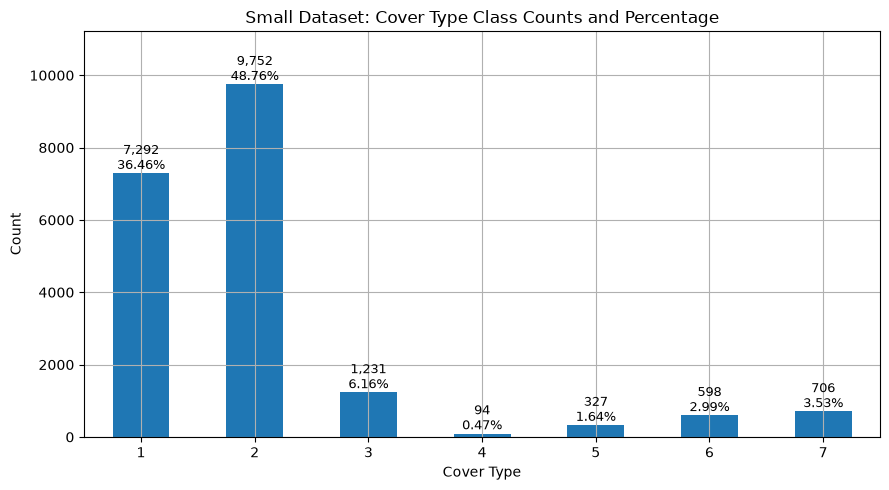

In [10]:
# plotting the data assesment with combined percentages and counts in a single chart

class_summary = (
    pd.DataFrame({
        "Count": class_counts,
        "Percent": class_pct
    })
    .sort_index()
)

ax = class_summary["Count"].plot(kind="bar", figsize=(9,5))

ax.set_title("Small Dataset: Cover Type Class Counts and Percentage")
ax.set_xlabel("Cover Type")
ax.set_ylabel("Count")
plt.xticks(rotation=0)

# adding count and percent labels above each bar
for i, (cover_type, row) in enumerate(class_summary.iterrows()):
    count = int(row["Count"])
    percent = row["Percent"]

    ax.text(
        i,
        count,
        f"{count:,}\n{percent:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# adding headroom for labels fit
ax.set_ylim(0, class_summary["Count"].max() * 1.15)

plt.tight_layout()
plt.savefig(FIG_EDA_DIR / "01_cover_type_class_counts_and_percentage.png", dpi=160, bbox_inches="tight")
plt.show()

### Initial target-distribution assessment
The small dataset preserves the same major class-imbalance pattern expected from the full Covertype dataset. Cover Types 1 and 2 dominate the sample, while Cover Types 4, 5, 6, and 7 are much smaller. Cover Type 4 is especially rare. This means accuracy alone can overstate model quality, so later model comparison should include macro-F1, weighted-F1, balanced accuracy, and confusion matrices.

## 4. Assessing continuous features

Checking how the continuous cartographic features are distributed is crucial for understanding scale, spread, outliers, and whether scaling is needed for kNN, SVM, and neural networks.

In [11]:
continuous_summary = df[continuous_cols].describe().T
continuous_summary.to_csv(RESULTS_METRICS_DIR / "continuous_summary.csv", index=False)
continuous_summary

,count,mean,std,min,25%,50%,75%,max
Elevation,20000.0,2958.79240,279.368995,1876.0,2807.0,2995.0,3164.0,3856.0
Aspect,20000.0,155.77895,111.849134,0.0,59.0,128.0,261.0,360.0
Slope,20000.0,14.12805,7.532004,0.0,9.0,13.0,18.0,51.0
Horizontal_Distance_To_Hydrology,20000.0,270.35255,213.677721,0.0,108.0,218.0,390.0,1397.0
Vertical_Distance_To_Hydrology,20000.0,46.94800,58.879064,-152.0,7.0,30.0,70.0,550.0
Horizontal_Distance_To_Roadways,20000.0,2349.68325,1555.032498,0.0,1104.0,2002.0,3318.0,7039.0
Hillshade_9am,20000.0,212.09520,27.026292,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,20000.0,223.32525,19.646602,87.0,213.0,226.0,237.0,254.0
Hillshade_3pm,20000.0,142.59270,38.279569,0.0,119.0,143.0,169.0,252.0
Horizontal_Distance_To_Fire_Points,20000.0,1986.75685,1327.894563,0.0,1026.0,1716.0,2554.0,7141.0


In [12]:
# addiontal diagnostics for extra spread
continuous_summary_extra = df[continuous_cols].agg(["mean", "std", "min", "median", "max"]).T
continuous_summary_extra["range"] = continuous_summary_extra["max"] = continuous_summary_extra["min"]
continuous_summary_extra.sort_values("range", ascending=False)
continuous_summary_extra.to_csv(RESULTS_METRICS_DIR / "continuous_summary_extra.csv", index=False)

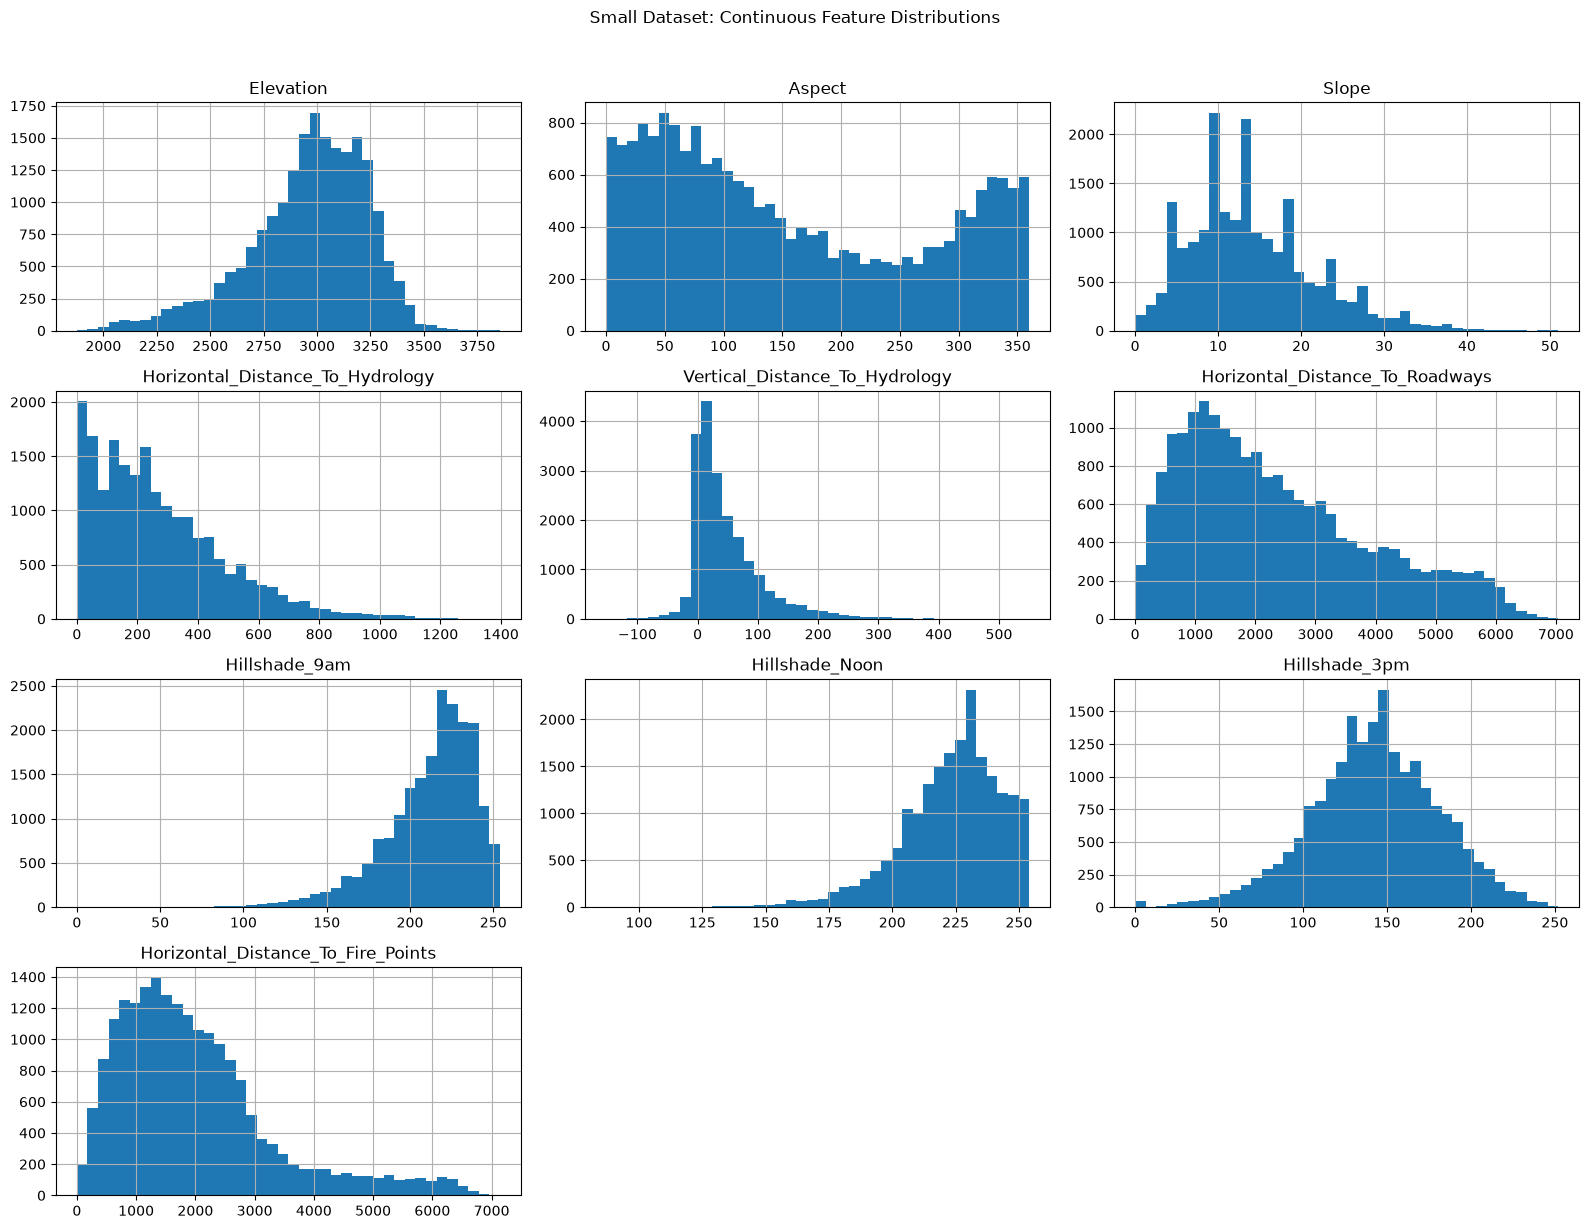

In [13]:
# plotting histograms for continuous features.
df[continuous_cols].hist(bins=40, figsize=(16, 12))
plt.suptitle("Small Dataset: Continuous Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig(FIG_EDA_DIR / "02_continuous_feature_histograms.png", dpi=160, bbox_inches="tight")
plt.show()

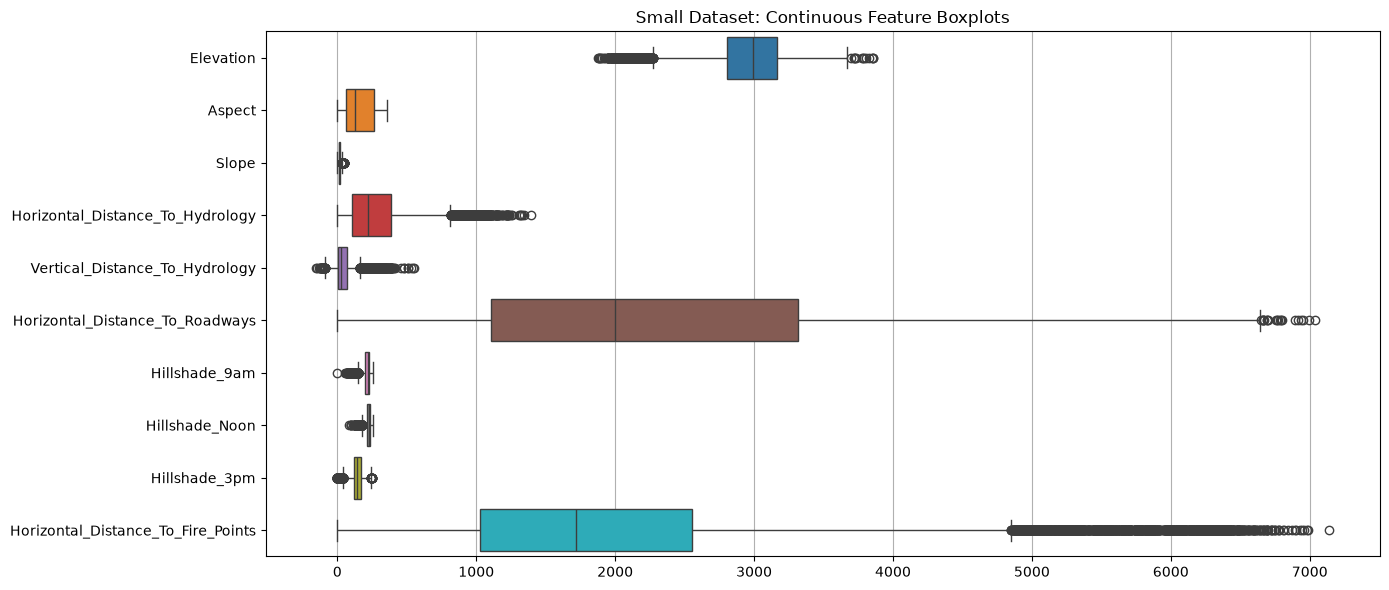

In [14]:
# Inspecting spread and potential outliers with boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[continuous_cols], orient="h")
plt.title("Small Dataset: Continuous Feature Boxplots")
plt.tight_layout()
plt.savefig(FIG_EDA_DIR / "03_continuous_feature_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Assessing continuous features by target class
This helps identify which features may separate forest cover types.

In [15]:
class_feature_means = df.groupby(target_col)[continuous_cols].mean().round(2)
class_feature_means.to_csv(RESULTS_METRICS_DIR / "class_feature_means.csv", index=False)
class_feature_means

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
Cover_Type,,,,,,,,,,
1,3128.81,155.12,13.15,269.25,42.42,2620.18,212.03,223.29,143.63,2012.45
2,2919.41,152.68,13.54,283.24,46.82,2426.09,213.73,225.46,143.29,2175.32
3,2397.61,176.70,20.56,207.38,62.03,945.76,202.51,216.49,140.66,921.02
4,2217.72,150.77,18.40,118.34,46.00,953.30,228.43,219.33,113.90,842.21
5,2789.80,142.67,17.27,230.84,54.88,1355.80,223.17,218.48,121.31,1606.11
6,2418.38,183.05,19.10,164.33,47.41,1012.91,191.83,209.51,149.17,1043.95
7,3359.89,152.58,14.87,341.92,65.20,2726.92,216.79,220.65,133.74,2102.31


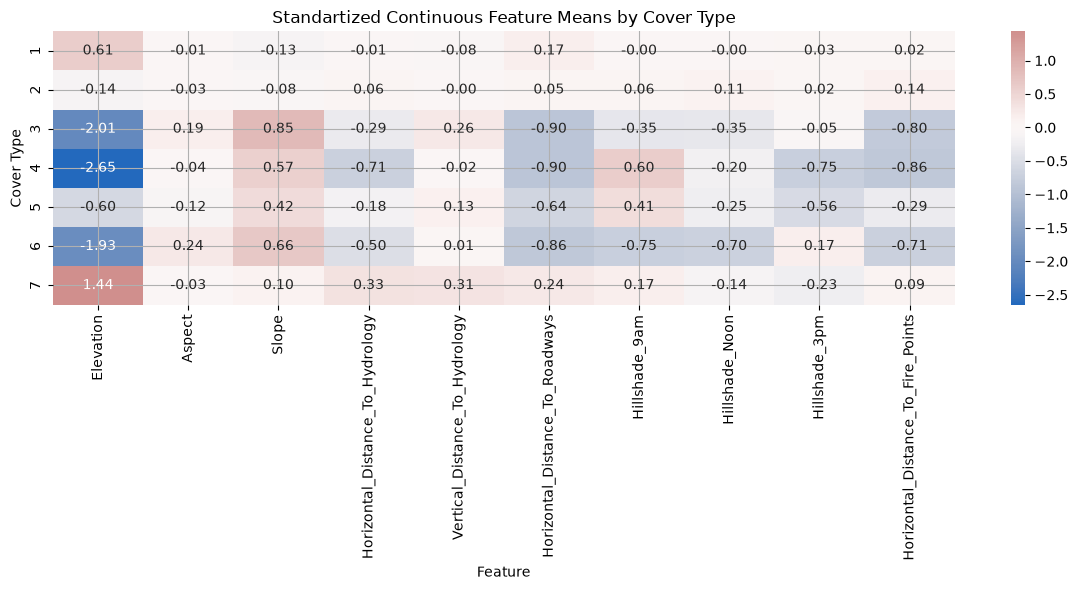

In [16]:
# Heatmap of class feature means after simple standartization for visuzliation only
standartized_class_means = class_feature_means.copy()
standartized_class_means = (standartized_class_means - df[continuous_cols].mean()) / df[continuous_cols].std()

plt.figure(figsize=(12, 6))
sns.heatmap(standartized_class_means, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Standartized Continuous Feature Means by Cover Type")
plt.xlabel("Feature")
plt.ylabel("Cover Type")
plt.tight_layout()
plt.savefig(FIG_EDA_DIR / "04_standardized_feature_means_by_cover_type.png", dpi=160, bbox_inches="tight")
plt.show()    

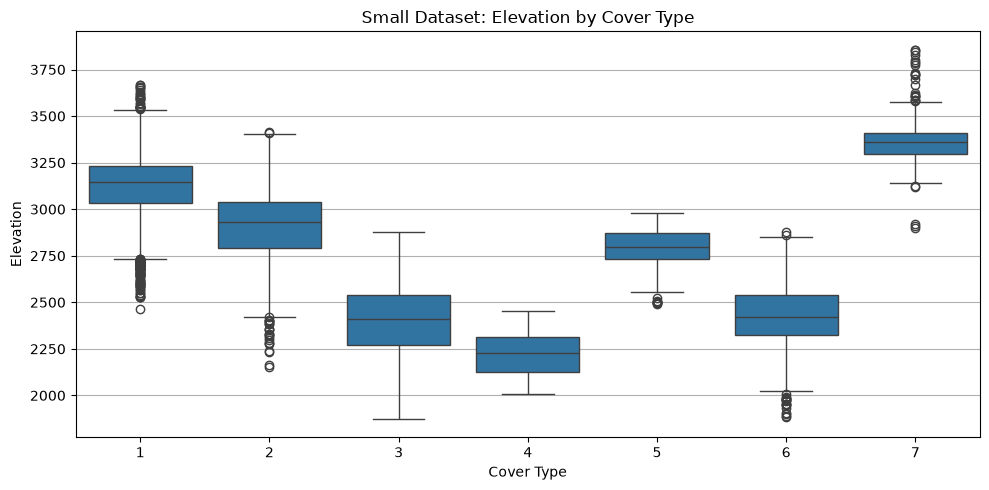

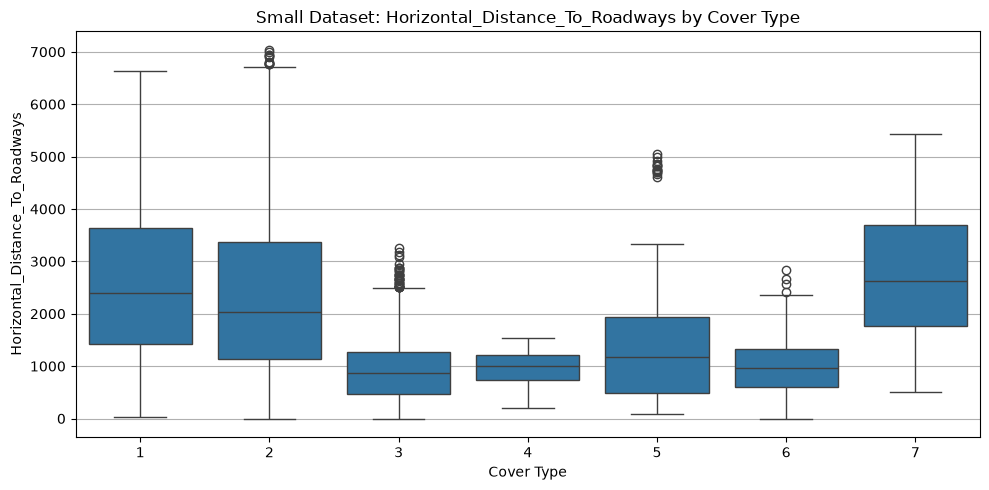

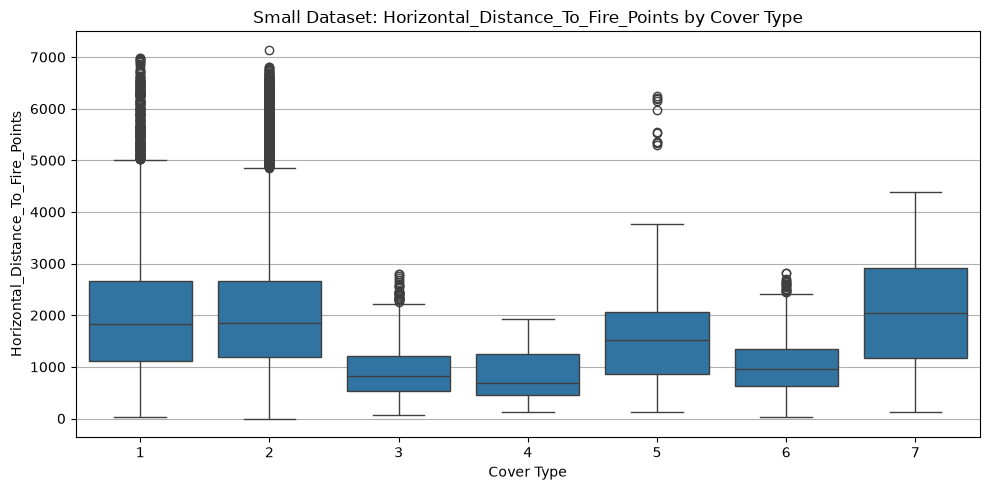

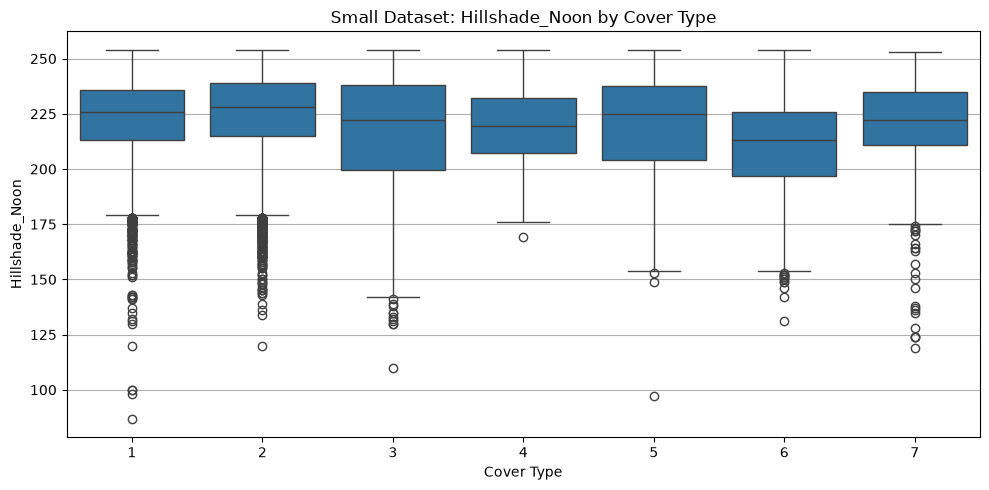

In [17]:
# Boxplots for selected high-signal features by target class.
selected_features_by_class = [
    "Elevation",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points",
    "Hillshade_Noon",
]

for col in selected_features_by_class:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f"Small Dataset: {col} by Cover Type")
    plt.xlabel("Cover Type")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(FIG_EDA_DIR / "05_boxplot_by_cover_type.png", dpi=160, bbox_inches="tight")
    plt.show()

## 6. Binary wilderness-area and soil-type feature analysis

The dataset has many binary indicator features. For each row, wilderness area and soil type are represented using one-hot encoded columns. This section checks how common or rare those indicators are.

In [18]:
wilderness_counts = df[wilderness_cols].sum().sort_values(ascending=False)
wilderness_pct = wilderness_counts / len(df) * 100

wilderness_distribution = pd.DataFrame({
    "count": wilderness_counts,
    "percent": wilderness_pct.round(3)
})
wilderness_distribution.to_csv(RESULTS_METRICS_DIR / "wilderness_distribution.csv", index=False)
wilderness_distribution

,count,percent
Wilderness_Area_1,8965,44.825
Wilderness_Area_3,8750,43.750
Wilderness_Area_4,1272,6.360
Wilderness_Area_2,1013,5.065


<function matplotlib.pyplot.show(close=None, block=None)>

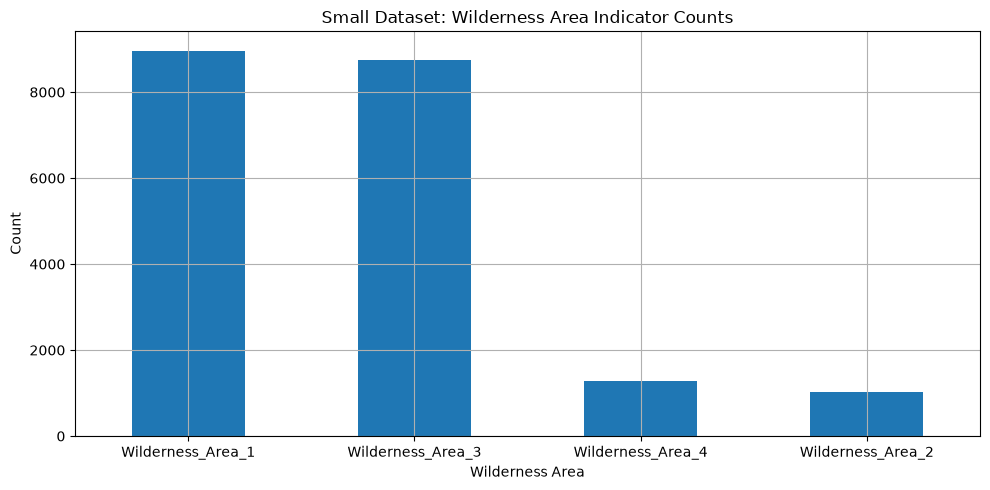

In [19]:
ax = wilderness_counts.plot(kind="bar")
ax.set_title("Small Dataset: Wilderness Area Indicator Counts")
ax.set_xlabel("Wilderness Area")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_EDA_DIR / "06_wilderness_area_counts.png", dpi=160, bbox_inches="tight")
plt.show

In [20]:
soil_counts = df[soil_cols].sum().sort_values(ascending=False)
soil_pct = soil_counts / len(df) * 100

soil_distribution = pd.DataFrame({
    "count": soil_counts,
    "percent": soil_pct.round(3)
})
soil_distribution.to_csv(RESULTS_METRICS_DIR / "soil_distribution.csv", index=False)
soil_distribution.head(15)

,count,percent
Soil_Type_29,3882,19.410
Soil_Type_23,2012,10.060
Soil_Type_32,1799,8.995
Soil_Type_33,1596,7.980
Soil_Type_22,1143,5.715
Soil_Type_10,1102,5.510
Soil_Type_12,1065,5.325
Soil_Type_30,1058,5.290
Soil_Type_31,905,4.525
Soil_Type_24,710,3.550


<function matplotlib.pyplot.show(close=None, block=None)>

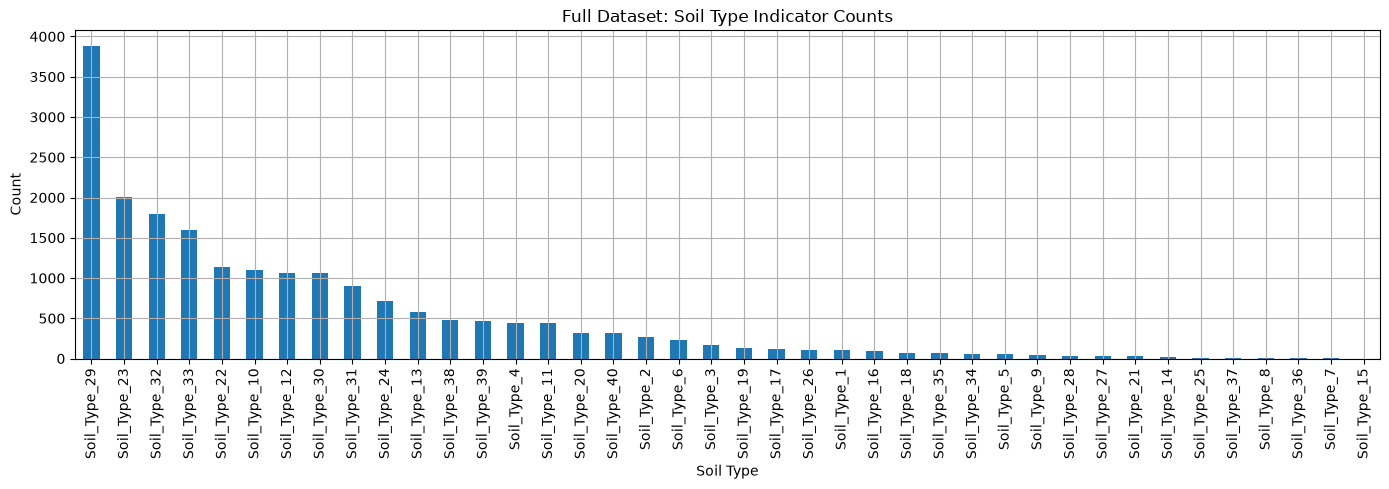

In [21]:
plt.figure(figsize=(14, 5))
soil_counts.plot(kind="bar")
plt.title("Full Dataset: Soil Type Indicator Counts")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIG_EDA_DIR / "07_soil_type_counts.png", dpi=160, bbox_inches="tight")
plt.show

In [22]:
rare_soil_types = soil_distribution[soil_distribution["percent"] < 1.0]
rare_soil_types.to_csv(RESULTS_METRICS_DIR / "rare_soil_types.csv", index=False)
rare_soil_types

,count,percent
Soil_Type_3,162,0.810
Soil_Type_19,132,0.660
Soil_Type_17,116,0.580
Soil_Type_26,109,0.545
Soil_Type_1,104,0.520
Soil_Type_16,97,0.485
Soil_Type_18,74,0.370
Soil_Type_35,71,0.355
Soil_Type_34,61,0.305
Soil_Type_5,58,0.290


In [23]:
# Checking each row because it should have exactly one wilderness are and one wilderness area type active
one_of_two_checks = pd.DataFrame({
    "wilderness_active_count": df[wilderness_cols].sum(axis=1).value_counts().sort_index(),
    "soil_active_count": df[soil_cols].sum(axis=1).value_counts().sort_index(),
})
one_of_two_checks.to_csv(RESULTS_METRICS_DIR / "one_of_two_checks.csv", index=False)
one_of_two_checks

print("Rows with exactly one wilderness area:", (df[wilderness_cols].sum(axis=1) == 1).mean() * 100, "%")
print("Rows with exactly one soil type:", (df[soil_cols].sum(axis=1) == 1).mean() * 100, "%")

Rows with exactly one wilderness area: 100.0 %
Rows with exactly one soil type: 100.0 %


# 7. Checking for consistenc
Each row should have exactly one wilderness area and exactly one soil type active

In [24]:
consist_checks = pd.DataFrame({
    "wilderness_active_count": df[wilderness_cols].sum(axis=1).value_counts().sort_index(),
    "soil_active_count": df[soil_cols].sum(axis=1).value_counts().sort_index(),
})
consist_checks.to_csv(RESULTS_METRICS_DIR / "consist_checks.csv", index=False)
consist_checks

wilderness_exactly_one_pct = (df[wilderness_cols].sum(axis=1) == 1).mean() * 100
soil_exactly_one_pct = (df[soil_cols].sum(axis=1) == 1).mean() * 100

print(f"Rows with exactly one wilderness area: {wilderness_exactly_one_pct:.2f}%")
print(f"Rows with exactly one soil type: {soil_exactly_one_pct:.2f}%")

Rows with exactly one wilderness area: 100.00%
Rows with exactly one soil type: 100.00%


## 8. Correlation analysis for continuous features
Correlation is most meaningful for the continuous features. The one-hot binary columns are better analyzed through frequencies and class relationships.

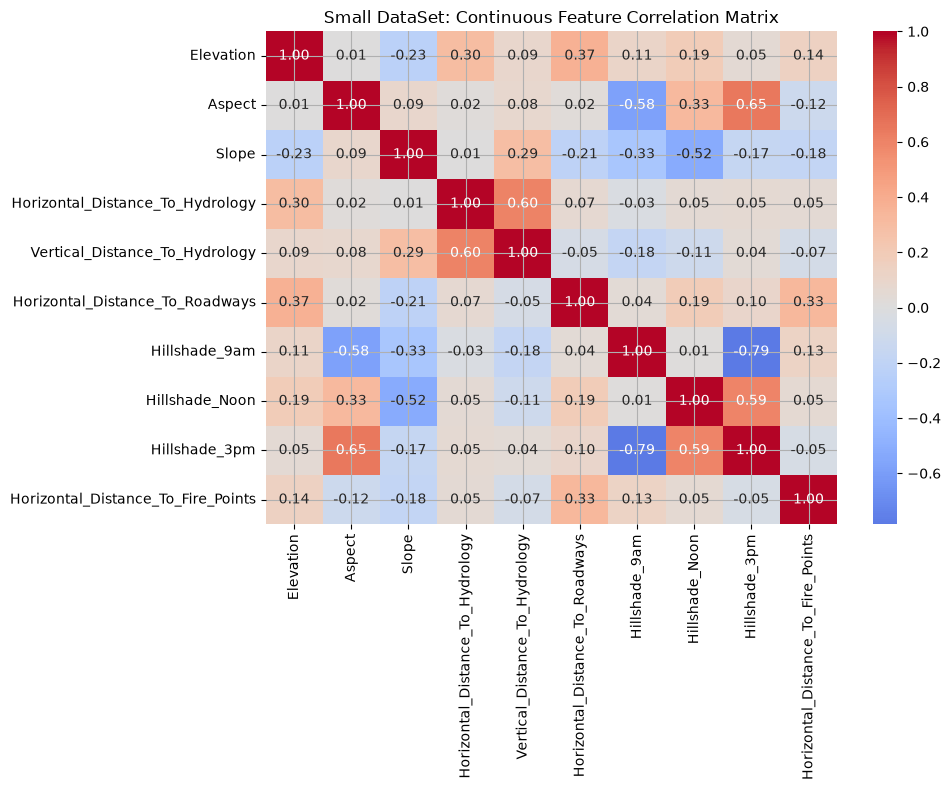

In [25]:
continuous_corr = df[continuous_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(continuous_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Small DataSet: Continuous Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIG_EDA_DIR / "08_continuous_feature_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

In [26]:
# listing strongest absolute correlations, excluding self-correlation
corr_pairs = (
    continuous_corr
    .where(np.triu(np.ones(continuous_corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
strongest_pairs = corr_pairs.sort_values("abs_correlation", ascending=False).head(10)
strongest_pairs.to_csv(RESULTS_METRICS_DIR / "correlation_pairs.csv", index=False)
strongest_pairs

,feature_1,feature_2,correlation,abs_correlation
68,Hillshade_9am,Hillshade_3pm,-0.785268,0.785268
18,Aspect,Hillshade_3pm,0.646068,0.646068
34,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,0.604659,0.604659
78,Hillshade_Noon,Hillshade_3pm,0.588583,0.588583
16,Aspect,Hillshade_9am,-0.581339,0.581339
27,Slope,Hillshade_Noon,-0.523749,0.523749
5,Elevation,Horizontal_Distance_To_Roadways,0.368522,0.368522
59,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,0.333831,0.333831
26,Slope,Hillshade_9am,-0.332452,0.332452
17,Aspect,Hillshade_Noon,0.329016,0.329016
